In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Generate Marketing Funnel Data
n = 10000

df = pd.DataFrame({
    'customer_id': range(1, n+1),
    'channel': np.random.choice(['Social Media', 'Email', 'SEO', 'Paid Ads', 'Referral'], n,
                                p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    'age_group': np.random.choice(['18-25', '26-35', '36-45', '46-55', '55+'], n),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'visited': [1]*n,
    'leads': np.random.choice([0,1], n, p=[0.40, 0.60]),
    'qualified': np.random.choice([0,1], n, p=[0.65, 0.35]),
    'proposed': np.random.choice([0,1], n, p=[0.70, 0.30]),
    'converted': np.random.choice([0,1], n, p=[0.80, 0.20]),
    'revenue': np.random.uniform(100, 5000, n).round(2)
})

# Make funnel logical
df['qualified'] = df['qualified'] * df['leads']
df['proposed'] = df['proposed'] * df['qualified']
df['converted'] = df['converted'] * df['proposed']
df['revenue'] = df['revenue'] * df['converted']

print("Dataset created successfully!")
print("Shape:", df.shape)
df.head()

Dataset created successfully!
Shape: (10000, 10)


,customer_id,channel,age_group,region,visited,leads,qualified,proposed,converted,revenue
0,1,Email,46-55,West,1,1,1,0,0,0.0
1,2,Referral,26-35,East,1,1,0,0,0,0.0
2,3,SEO,55+,East,1,0,0,0,0,0.0
3,4,SEO,36-45,North,1,1,0,0,0,0.0
4,5,Social Media,36-45,South,1,0,0,0,0,0.0


In [3]:
# Calculate Funnel Metrics
total_visitors = df['visited'].sum()
total_leads = df['leads'].sum()
total_qualified = df['qualified'].sum()
total_proposed = df['proposed'].sum()
total_converted = df['converted'].sum()
total_revenue = df['revenue'].sum()

print("=" * 45)
print("      MARKETING FUNNEL KPI SUMMARY")
print("=" * 45)
print(f"Total Visitors    : {total_visitors:,}")
print(f"Total Leads       : {total_leads:,}")
print(f"Total Qualified   : {total_qualified:,}")
print(f"Total Proposed    : {total_proposed:,}")
print(f"Total Converted   : {total_converted:,}")
print(f"Total Revenue     : ${total_revenue:,.2f}")
print("-" * 45)
print(f"Visitor to Lead   : {total_leads/total_visitors*100:.2f}%")
print(f"Lead to Qualified : {total_qualified/total_leads*100:.2f}%")
print(f"Qualified to Prop : {total_proposed/total_qualified*100:.2f}%")
print(f"Proposed to Conv  : {total_converted/total_proposed*100:.2f}%")
print(f"Overall Conv Rate : {total_converted/total_visitors*100:.2f}%")
print("=" * 45)

      MARKETING FUNNEL KPI SUMMARY
Total Visitors    : 10,000
Total Leads       : 5,950
Total Qualified   : 2,069
Total Proposed    : 598
Total Converted   : 110
Total Revenue     : $266,548.73
---------------------------------------------
Visitor to Lead   : 59.50%
Lead to Qualified : 34.77%
Qualified to Prop : 28.90%
Proposed to Conv  : 18.39%
Overall Conv Rate : 1.10%


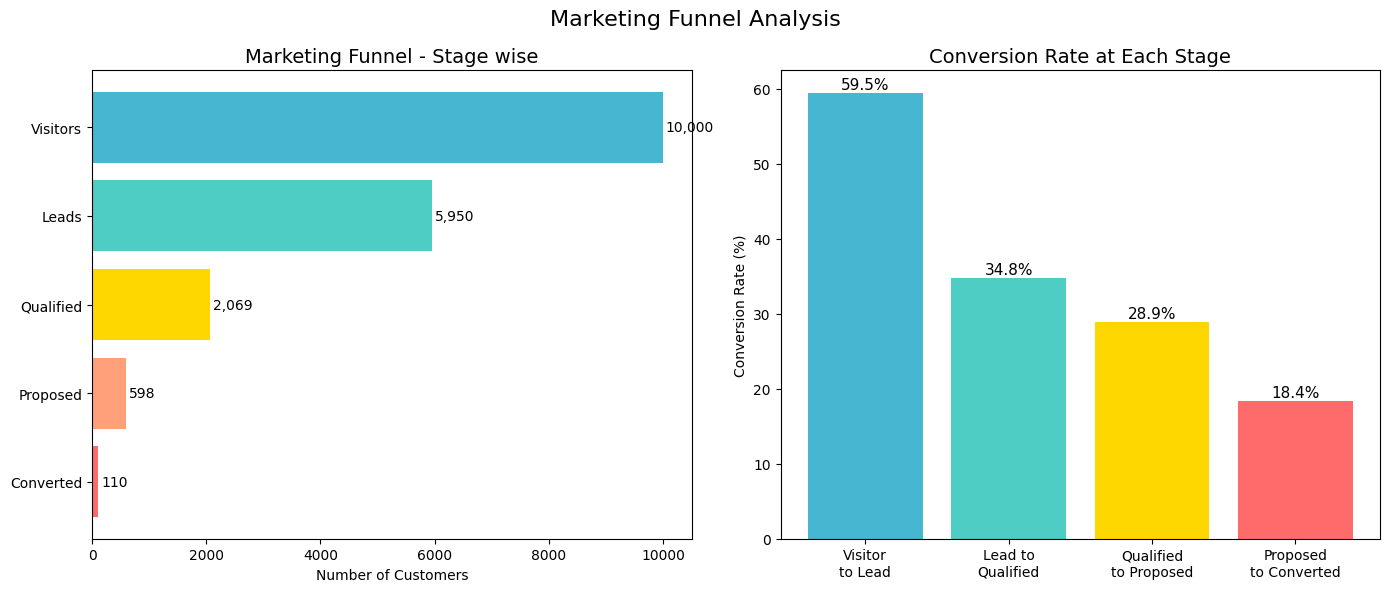

Chart 1 done! ✅


In [4]:
# Funnel Visualization
stages = ['Visitors', 'Leads', 'Qualified', 'Proposed', 'Converted']
values = [total_visitors, total_leads, total_qualified,
          total_proposed, total_converted]
colors = ['#45B7D1', '#4ECDC4', '#FFD700', '#FFA07A', '#FF6B6B']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Funnel
axes[0].barh(stages[::-1], values[::-1], color=colors[::-1])
axes[0].set_title('Marketing Funnel - Stage wise', fontsize=14)
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(values[::-1]):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=10)

# Conversion Rate at each stage
conv_rates = [
    total_leads/total_visitors*100,
    total_qualified/total_leads*100,
    total_proposed/total_qualified*100,
    total_converted/total_proposed*100
]
stage_labels = ['Visitor\nto Lead', 'Lead to\nQualified',
                'Qualified\nto Proposed', 'Proposed\nto Converted']

axes[1].bar(stage_labels, conv_rates,
            color=['#45B7D1', '#4ECDC4', '#FFD700', '#FF6B6B'])
axes[1].set_title('Conversion Rate at Each Stage', fontsize=14)
axes[1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conv_rates):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Marketing Funnel Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 1 done! ✅")

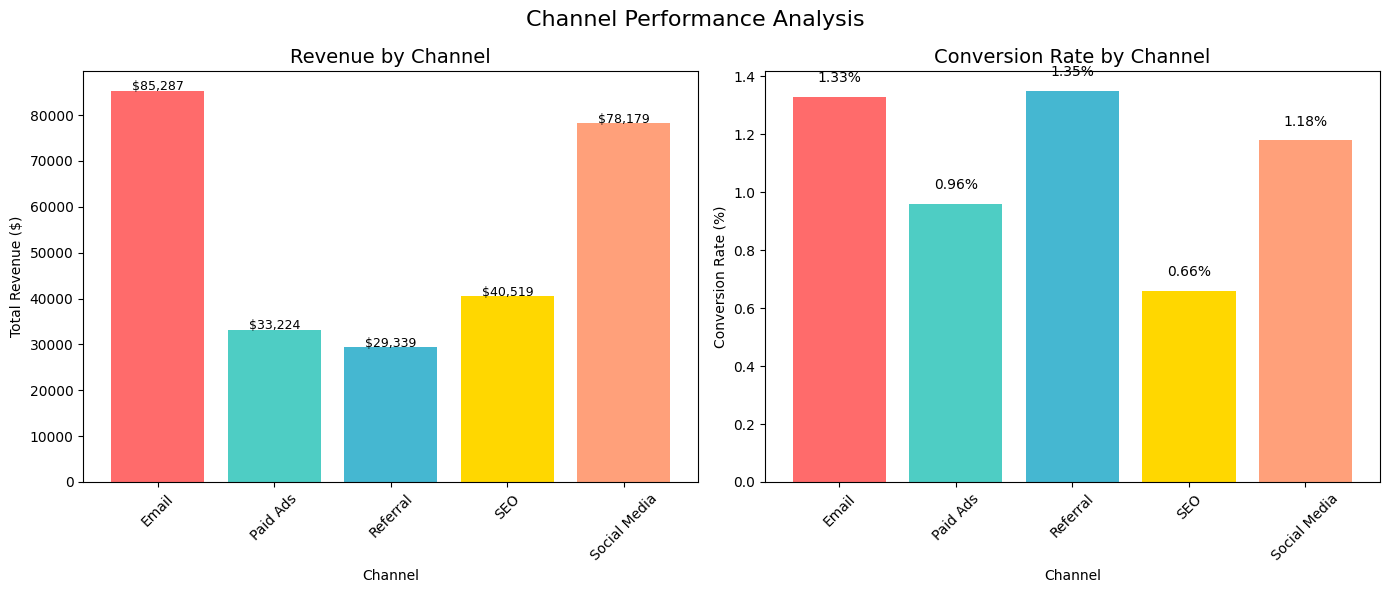

Chart 2 done! ✅


In [5]:
# Channel Performance
channel_perf = df.groupby('channel').agg(
    Visitors=('visited', 'sum'),
    Leads=('leads', 'sum'),
    Qualified=('qualified', 'sum'),
    Converted=('converted', 'sum'),
    Revenue=('revenue', 'sum')
).reset_index()

channel_perf['Conversion_Rate'] = (channel_perf['Converted'] /
                                    channel_perf['Visitors'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue by Channel
axes[0].bar(channel_perf['channel'], channel_perf['Revenue'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
axes[0].set_title('Revenue by Channel', fontsize=14)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(channel_perf['Revenue']):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)

# Conversion Rate by Channel
axes[1].bar(channel_perf['channel'], channel_perf['Conversion_Rate'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
axes[1].set_title('Conversion Rate by Channel', fontsize=14)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(channel_perf['Conversion_Rate']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)

plt.suptitle('Channel Performance Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 2 done! ✅")

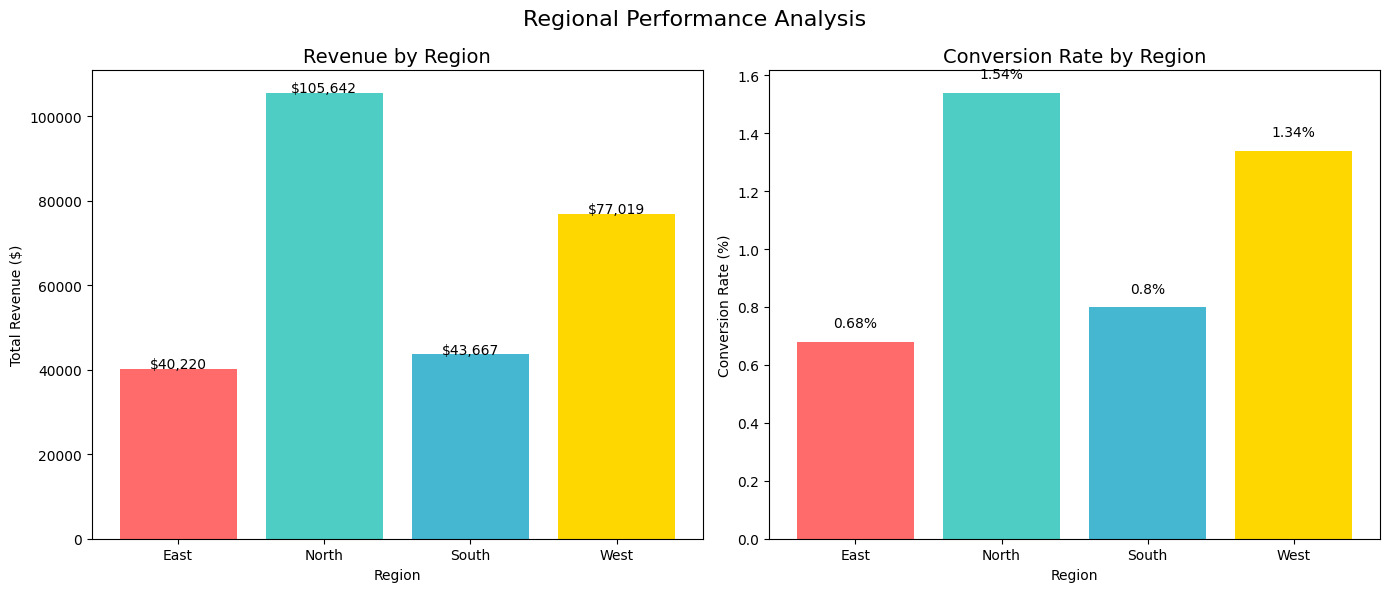

Chart 3 done! ✅


In [6]:
# Regional Performance
region_perf = df.groupby('region').agg(
    Visitors=('visited', 'sum'),
    Leads=('leads', 'sum'),
    Converted=('converted', 'sum'),
    Revenue=('revenue', 'sum')
).reset_index()

region_perf['Conversion_Rate'] = (region_perf['Converted'] /
                                   region_perf['Visitors'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue by Region
axes[0].bar(region_perf['region'], region_perf['Revenue'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700'])
axes[0].set_title('Revenue by Region', fontsize=14)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Revenue ($)')
for i, v in enumerate(region_perf['Revenue']):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=10)

# Conversion Rate by Region
axes[1].bar(region_perf['region'], region_perf['Conversion_Rate'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700'])
axes[1].set_title('Conversion Rate by Region', fontsize=14)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(region_perf['Conversion_Rate']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)

plt.suptitle('Regional Performance Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 3 done! ✅")

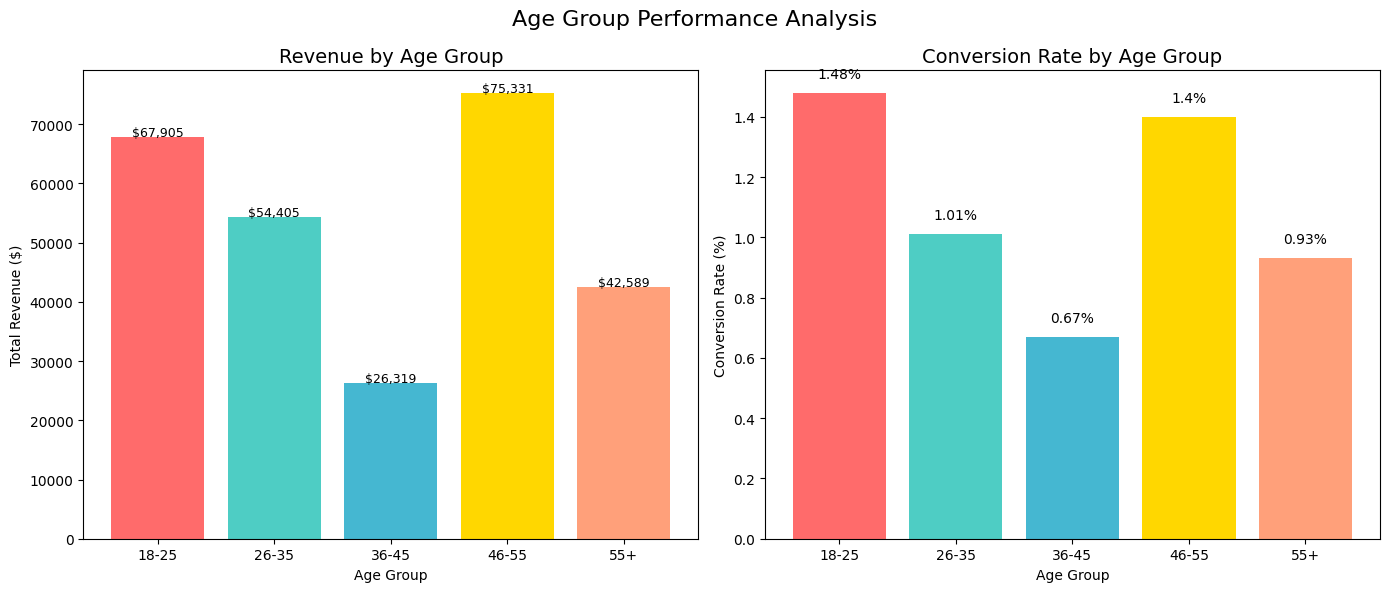

Chart 4 done! ✅


In [7]:
# Age Group Analysis
age_perf = df.groupby('age_group').agg(
    Visitors=('visited', 'sum'),
    Leads=('leads', 'sum'),
    Converted=('converted', 'sum'),
    Revenue=('revenue', 'sum')
).reset_index()

age_perf['Conversion_Rate'] = (age_perf['Converted'] /
                                age_perf['Visitors'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue by Age Group
axes[0].bar(age_perf['age_group'], age_perf['Revenue'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
axes[0].set_title('Revenue by Age Group', fontsize=14)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Total Revenue ($)')
for i, v in enumerate(age_perf['Revenue']):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)

# Conversion Rate by Age Group
axes[1].bar(age_perf['age_group'], age_perf['Conversion_Rate'],
            color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
axes[1].set_title('Conversion Rate by Age Group', fontsize=14)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(age_perf['Conversion_Rate']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)

plt.suptitle('Age Group Performance Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 4 done! ✅")

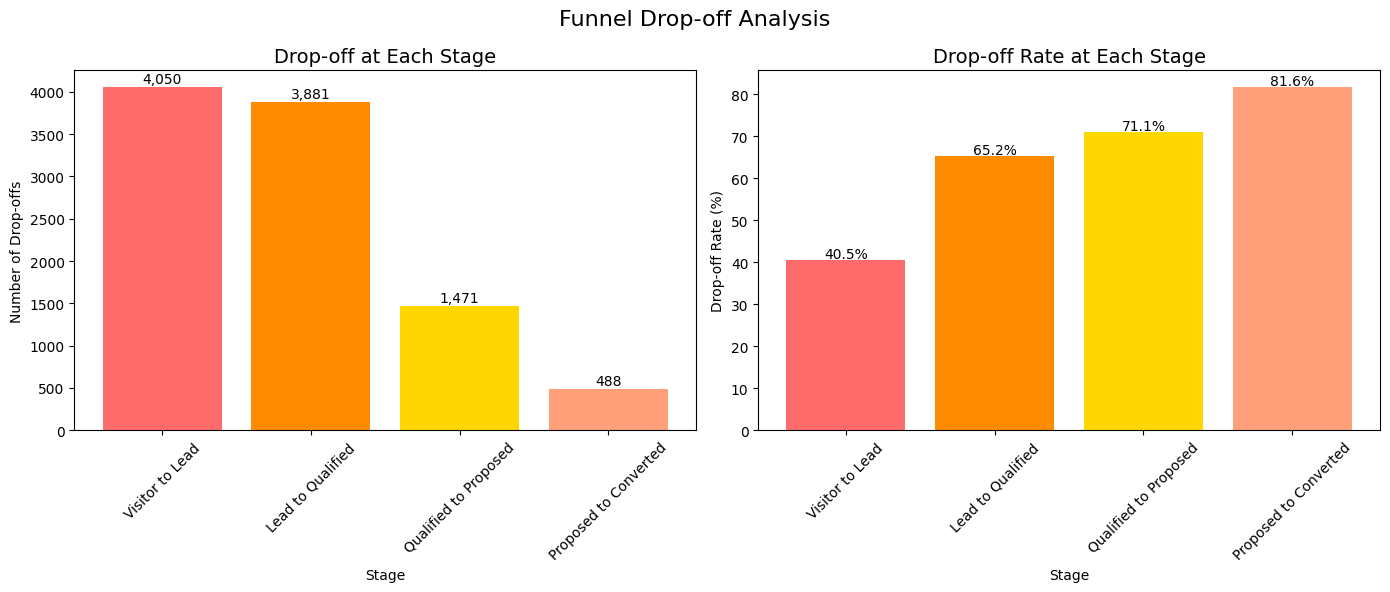

Chart 5 done! ✅


In [8]:
# Drop-off Analysis
stages = ['Visitors', 'Leads', 'Qualified', 'Proposed', 'Converted']
values = [total_visitors, total_leads, total_qualified,
          total_proposed, total_converted]

dropoffs = []
for i in range(len(values)-1):
    dropoffs.append(values[i] - values[i+1])

dropoff_labels = ['Visitor to Lead', 'Lead to Qualified',
                  'Qualified to Proposed', 'Proposed to Converted']
dropoff_pct = [d/values[i]*100 for i, d in enumerate(dropoffs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Drop-off Numbers
axes[0].bar(dropoff_labels, dropoffs,
            color=['#FF6B6B','#FF8C00','#FFD700','#FFA07A'])
axes[0].set_title('Drop-off at Each Stage', fontsize=14)
axes[0].set_xlabel('Stage')
axes[0].set_ylabel('Number of Drop-offs')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(dropoffs):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Drop-off Percentage
axes[1].bar(dropoff_labels, dropoff_pct,
            color=['#FF6B6B','#FF8C00','#FFD700','#FFA07A'])
axes[1].set_title('Drop-off Rate at Each Stage', fontsize=14)
axes[1].set_xlabel('Stage')
axes[1].set_ylabel('Drop-off Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(dropoff_pct):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Funnel Drop-off Analysis', fontsize=16)
plt.tight_layout()
plt.show()
print("Chart 5 done! ✅")

In [9]:
print("=" * 50)
print("    MARKETING FUNNEL INSIGHTS & FINDINGS")
print("=" * 50)

# Best and Worst Channel
best_channel = channel_perf.loc[channel_perf['Conversion_Rate'].idxmax(), 'channel']
worst_channel = channel_perf.loc[channel_perf['Conversion_Rate'].idxmin(), 'channel']
print(f"\n✅ Best Channel by Conversion  : {best_channel}")
print(f"❌ Worst Channel by Conversion : {worst_channel}")

# Best Revenue Channel
best_rev_channel = channel_perf.loc[channel_perf['Revenue'].idxmax(), 'channel']
print(f"✅ Best Channel by Revenue     : {best_rev_channel}")

# Best and Worst Region
best_region = region_perf.loc[region_perf['Conversion_Rate'].idxmax(), 'region']
worst_region = region_perf.loc[region_perf['Conversion_Rate'].idxmin(), 'region']
print(f"\n✅ Best Region by Conversion   : {best_region}")
print(f"❌ Worst Region by Conversion  : {worst_region}")

# Best Age Group
best_age = age_perf.loc[age_perf['Conversion_Rate'].idxmax(), 'age_group']
print(f"\n✅ Best Age Group by Conversion: {best_age}")

# Biggest Drop-off
biggest_dropoff = dropoff_labels[dropoff_pct.index(max(dropoff_pct))]
print(f"\n❌ Biggest Drop-off Stage      : {biggest_dropoff}")
print(f"❌ Biggest Drop-off Rate       : {max(dropoff_pct):.1f}%")

# Overall Metrics
print(f"\n📊 Overall Conversion Rate     : {total_converted/total_visitors*100:.2f}%")
print(f"📊 Total Revenue Generated     : ${total_revenue:,.2f}")
print(f"📊 Avg Revenue per Conversion  : ${total_revenue/total_converted:,.2f}")

print("\n" + "=" * 50)
print("Insights generated successfully! ✅")
print("=" * 50)

    MARKETING FUNNEL INSIGHTS & FINDINGS

✅ Best Channel by Conversion  : Referral
❌ Worst Channel by Conversion : SEO
✅ Best Channel by Revenue     : Email

✅ Best Region by Conversion   : North
❌ Worst Region by Conversion  : East

✅ Best Age Group by Conversion: 18-25

❌ Biggest Drop-off Stage      : Proposed to Converted
❌ Biggest Drop-off Rate       : 81.6%

📊 Overall Conversion Rate     : 1.10%
📊 Total Revenue Generated     : $266,548.73
📊 Avg Revenue per Conversion  : $2,423.17

Insights generated successfully! ✅


In [10]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('Marketing_Funnel_Analysis_Report.pdf') as pdf:

    # Page 1: Title Page
    fig = plt.figure(figsize=(12, 8))
    fig.patch.set_facecolor('#2C3E50')
    plt.text(0.5, 0.70, 'Marketing Funnel Analysis', ha='center',
             fontsize=30, color='white', fontweight='bold')
    plt.text(0.5, 0.55, 'Conversion & Drop-off Report', ha='center',
             fontsize=20, color='#4ECDC4')
    plt.text(0.5, 0.42, 'Total Visitors: 10,000', ha='center',
             fontsize=16, color='white')
    plt.text(0.5, 0.32, 'Overall Conversion: 1.10%  |  Revenue: $266,548.73', ha='center',
             fontsize=14, color='white')
    plt.text(0.5, 0.20, 'Prepared by: Induri Sai Chandu', ha='center',
             fontsize=12, color='#BDC3C7')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 2: Funnel Overview
    stages = ['Visitors', 'Leads', 'Qualified', 'Proposed', 'Converted']
    values = [total_visitors, total_leads, total_qualified,
              total_proposed, total_converted]
    colors = ['#45B7D1', '#4ECDC4', '#FFD700', '#FFA07A', '#FF6B6B']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].barh(stages[::-1], values[::-1], color=colors[::-1])
    axes[0].set_title('Funnel Stage wise', fontsize=14)
    axes[0].set_xlabel('Number of Customers')
    for i, v in enumerate(values[::-1]):
        axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=10)

    conv_rates = [
        total_leads/total_visitors*100,
        total_qualified/total_leads*100,
        total_proposed/total_qualified*100,
        total_converted/total_proposed*100
    ]
    stage_labels = ['Visitor\nto Lead', 'Lead to\nQualified',
                    'Qualified\nto Proposed', 'Proposed\nto Converted']
    axes[1].bar(stage_labels, conv_rates,
                color=['#45B7D1', '#4ECDC4', '#FFD700', '#FF6B6B'])
    axes[1].set_title('Conversion Rate by Stage', fontsize=14)
    axes[1].set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(conv_rates):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)
    plt.suptitle('Marketing Funnel Overview', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 3: Channel Performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].bar(channel_perf['channel'], channel_perf['Revenue'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
    axes[0].set_title('Revenue by Channel', fontsize=14)
    axes[0].set_xlabel('Channel')
    axes[0].set_ylabel('Total Revenue ($)')
    axes[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(channel_perf['Revenue']):
        axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)
    axes[1].bar(channel_perf['channel'], channel_perf['Conversion_Rate'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
    axes[1].set_title('Conversion Rate by Channel', fontsize=14)
    axes[1].set_xlabel('Channel')
    axes[1].set_ylabel('Conversion Rate (%)')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(channel_perf['Conversion_Rate']):
        axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)
    plt.suptitle('Channel Performance Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 4: Regional Performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].bar(region_perf['region'], region_perf['Revenue'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700'])
    axes[0].set_title('Revenue by Region', fontsize=14)
    axes[0].set_xlabel('Region')
    axes[0].set_ylabel('Total Revenue ($)')
    for i, v in enumerate(region_perf['Revenue']):
        axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=10)
    axes[1].bar(region_perf['region'], region_perf['Conversion_Rate'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700'])
    axes[1].set_title('Conversion Rate by Region', fontsize=14)
    axes[1].set_xlabel('Region')
    axes[1].set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(region_perf['Conversion_Rate']):
        axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)
    plt.suptitle('Regional Performance Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 5: Drop-off Analysis
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].bar(dropoff_labels, dropoffs,
                color=['#FF6B6B','#FF8C00','#FFD700','#FFA07A'])
    axes[0].set_title('Drop-off at Each Stage', fontsize=14)
    axes[0].set_xlabel('Stage')
    axes[0].set_ylabel('Number of Drop-offs')
    axes[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(dropoffs):
        axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
    axes[1].bar(dropoff_labels, dropoff_pct,
                color=['#FF6B6B','#FF8C00','#FFD700','#FFA07A'])
    axes[1].set_title('Drop-off Rate at Each Stage', fontsize=14)
    axes[1].set_xlabel('Stage')
    axes[1].set_ylabel('Drop-off Rate (%)')
    axes[1].tick_params(axis='x', rotation=45)
    for i, v in enumerate(dropoff_pct):
        axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
    plt.suptitle('Funnel Drop-off Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 6: Age Group Analysis
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].bar(age_perf['age_group'], age_perf['Revenue'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
    axes[0].set_title('Revenue by Age Group', fontsize=14)
    axes[0].set_xlabel('Age Group')
    axes[0].set_ylabel('Total Revenue ($)')
    for i, v in enumerate(age_perf['Revenue']):
        axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9)
    axes[1].bar(age_perf['age_group'], age_perf['Conversion_Rate'],
                color=['#FF6B6B','#4ECDC4','#45B7D1','#FFD700','#FFA07A'])
    axes[1].set_title('Conversion Rate by Age Group', fontsize=14)
    axes[1].set_xlabel('Age Group')
    axes[1].set_ylabel('Conversion Rate (%)')
    for i, v in enumerate(age_perf['Conversion_Rate']):
        axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=10)
    plt.suptitle('Age Group Performance Analysis', fontsize=16)
    plt.tight_layout()
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

    # Page 7: Recommendations
    fig = plt.figure(figsize=(12, 8))
    fig.patch.set_facecolor('#2C3E50')
    plt.text(0.5, 0.93, 'Key Insights and Recommendations', ha='center',
             fontsize=22, color='white', fontweight='bold')
    insights = [
        "- Biggest drop-off is at Proposed to Converted stage (81.6%)",
        "- Referral channel has the highest conversion rate",
        "- Email channel generates the highest revenue",
        "- SEO channel has the lowest conversion rate",
        "- North region outperforms all other regions",
        "- 18-25 age group has the highest conversion rate",
        "- Invest more budget in Referral and Email channels",
        "- Improve proposal quality to reduce 81.6% drop-off",
        "- Create targeted campaigns for 18-25 age group",
        "- Review and optimize SEO strategy for better conversions"
    ]
    for i, insight in enumerate(insights):
        plt.text(0.08, 0.82 - i*0.08, insight, fontsize=13, color='white')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

print("PDF Report generated successfully!")

PDF Report generated successfully!


In [11]:
from google.colab import files
files.download('Marketing_Funnel_Analysis_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>